# 📊 ETH OHLCV Data Exploration
## Using SQLite Database

This notebook explores Ethereum OHLCV (Open, High, Low, Close, Volume) data stored in SQLite database.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Connect to SQLite Database

In [ ]:
# Define database path
DATA_DIR = Path('..') / 'data'
db_path = DATA_DIR / 'ETH.db'

# Connect to SQLite database
conn = sqlite3.connect(db_path)

# Check if table exists
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("📋 Tables in database:")
print(tables)

📋 Tables in database:
          name
0    eth_daily
1    eth_ohlcv
2  eth_signals


In [3]:
# Load data from SQLite
query = "SELECT * FROM eth_ohlcv ORDER BY date"
df = pd.read_sql(query, conn, parse_dates=['date'])

# Close connection
conn.close()

print(f"✅ Loaded {len(df)} days of OHLCV data from SQLite")
print(f"📅 Period: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
df.head(10)

✅ Loaded 365 days of OHLCV data from SQLite
📅 Period: 2025-07-28 to 2026-07-27


,date,open,high,low,close,volume,SMA_7,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_signal,MACD_histogram,RSI_14,BB_middle,BB_upper,BB_lower,ATR_14
0,2025-07-28,3872.11,3941.00,3754.00,3799.00,620994.7463,NaN,NaN,NaN,3799.000000,3799.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,2025-07-29,3799.00,3886.44,3716.04,3793.79,584210.4393,NaN,NaN,NaN,3798.198462,3798.614074,-0.415613,-0.083123,-0.332490,NaN,NaN,NaN,NaN,NaN
2,2025-07-30,3793.79,3834.03,3677.65,3810.00,525424.9003,NaN,NaN,NaN,3800.014083,3799.457476,0.556607,0.044823,0.511783,NaN,NaN,NaN,NaN,NaN
3,2025-07-31,3810.00,3878.67,3684.33,3698.39,516088.4503,NaN,NaN,NaN,3784.379609,3791.970996,-7.591388,-1.482419,-6.108969,NaN,NaN,NaN,NaN,NaN
4,2025-08-01,3698.39,3724.02,3431.75,3488.20,783869.1517,NaN,NaN,NaN,3738.813515,3769.469441,-30.655926,-7.317120,-23.338806,NaN,NaN,NaN,NaN,NaN
5,2025-08-02,3488.21,3537.69,3368.29,3393.94,494195.7094,NaN,NaN,NaN,3685.756051,3741.652445,-55.896394,-17.032975,-38.863419,NaN,NaN,NaN,NaN,NaN
6,2025-08-03,3393.94,3521.79,3354.28,3496.74,296347.6758,3640.008571,NaN,NaN,3656.676659,3723.510783,-66.834124,-26.993205,-39.840919,NaN,NaN,NaN,NaN,NaN
7,2025-08-04,3496.75,3736.73,3490.73,3720.99,463349.9861,3628.864286,NaN,NaN,3666.571019,3723.324058,-56.753039,-32.945172,-23.807867,NaN,NaN,NaN,NaN,NaN
8,2025-08-05,3720.99,3722.24,3546.00,3612.00,489070.9589,3602.894286,NaN,NaN,3658.175477,3715.077832,-56.902354,-37.736608,-19.165746,NaN,NaN,NaN,NaN,NaN
9,2025-08-06,3612.01,3698.60,3564.19,3683.31,365309.9205,3584.795714,NaN,NaN,3662.042327,3712.724659,-50.682332,-40.325753,-10.356579,NaN,NaN,NaN,NaN,NaN


## 3. Basic Statistics

In [4]:
# Get basic statistics
print("📊 Basic Statistics:")
print("="*50)
df[['open', 'high', 'low', 'close', 'volume']].describe()

📊 Basic Statistics:


,open,high,low,close,volume
count,365.000000,365.000000,365.000000,365.000000,3.650000e+02
mean,2871.996219,2941.135479,2795.123671,2866.772082,4.354380e+05
std,952.695989,977.041334,927.253257,952.424441,2.773997e+05
min,1567.860000,1588.820000,1505.680000,1567.840000,6.813922e+04
25%,2051.970000,2093.940000,1991.000000,2048.720000,2.529811e+05
50%,2816.900000,2951.210000,2754.530000,2802.160000,3.896734e+05
75%,3746.800000,3878.300000,3564.190000,3720.990000,5.246051e+05
max,4832.070000,4956.780000,4711.000000,4832.070000,2.102312e+06


## 4. Check for Missing Values

In [5]:
print("🔍 Missing Values:")
df.isnull().sum()

🔍 Missing Values:


date               0
open               0
high               0
low                0
close              0
volume             0
SMA_7              6
SMA_20            19
SMA_50            49
EMA_12             0
EMA_26             0
MACD               0
MACD_signal        0
MACD_histogram     0
RSI_14            13
BB_middle         19
BB_upper          19
BB_lower          19
ATR_14            13
dtype: int64

## 5. Correlation Matrix

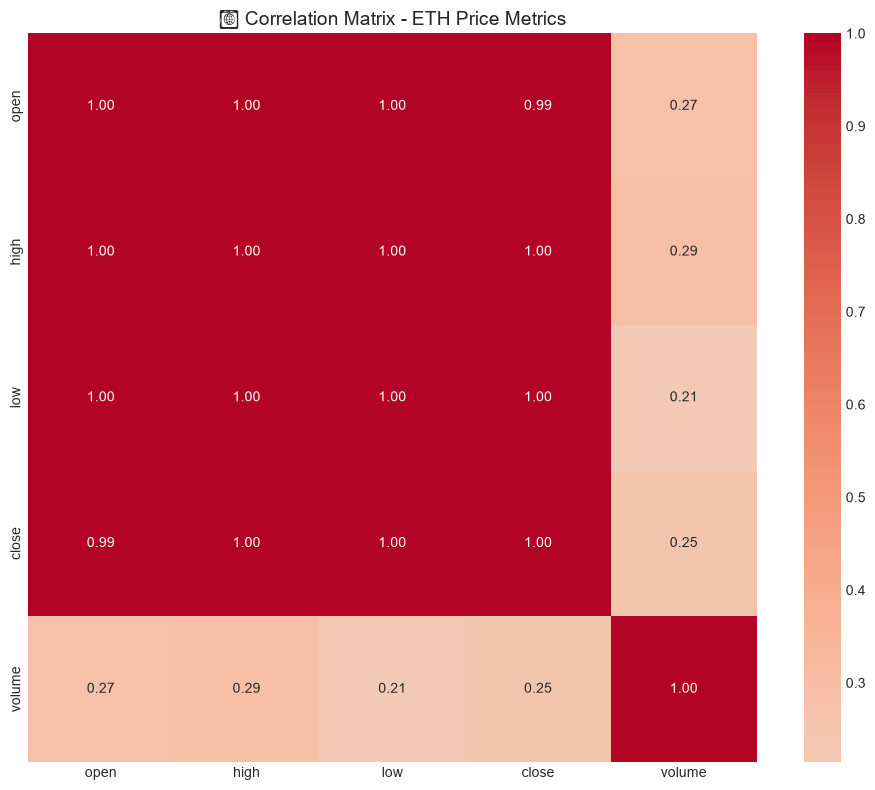

In [6]:
# Correlation matrix
correlation = df[['open', 'high', 'low', 'close', 'volume']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('📈 Correlation Matrix - ETH Price Metrics', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Price Distribution Analysis

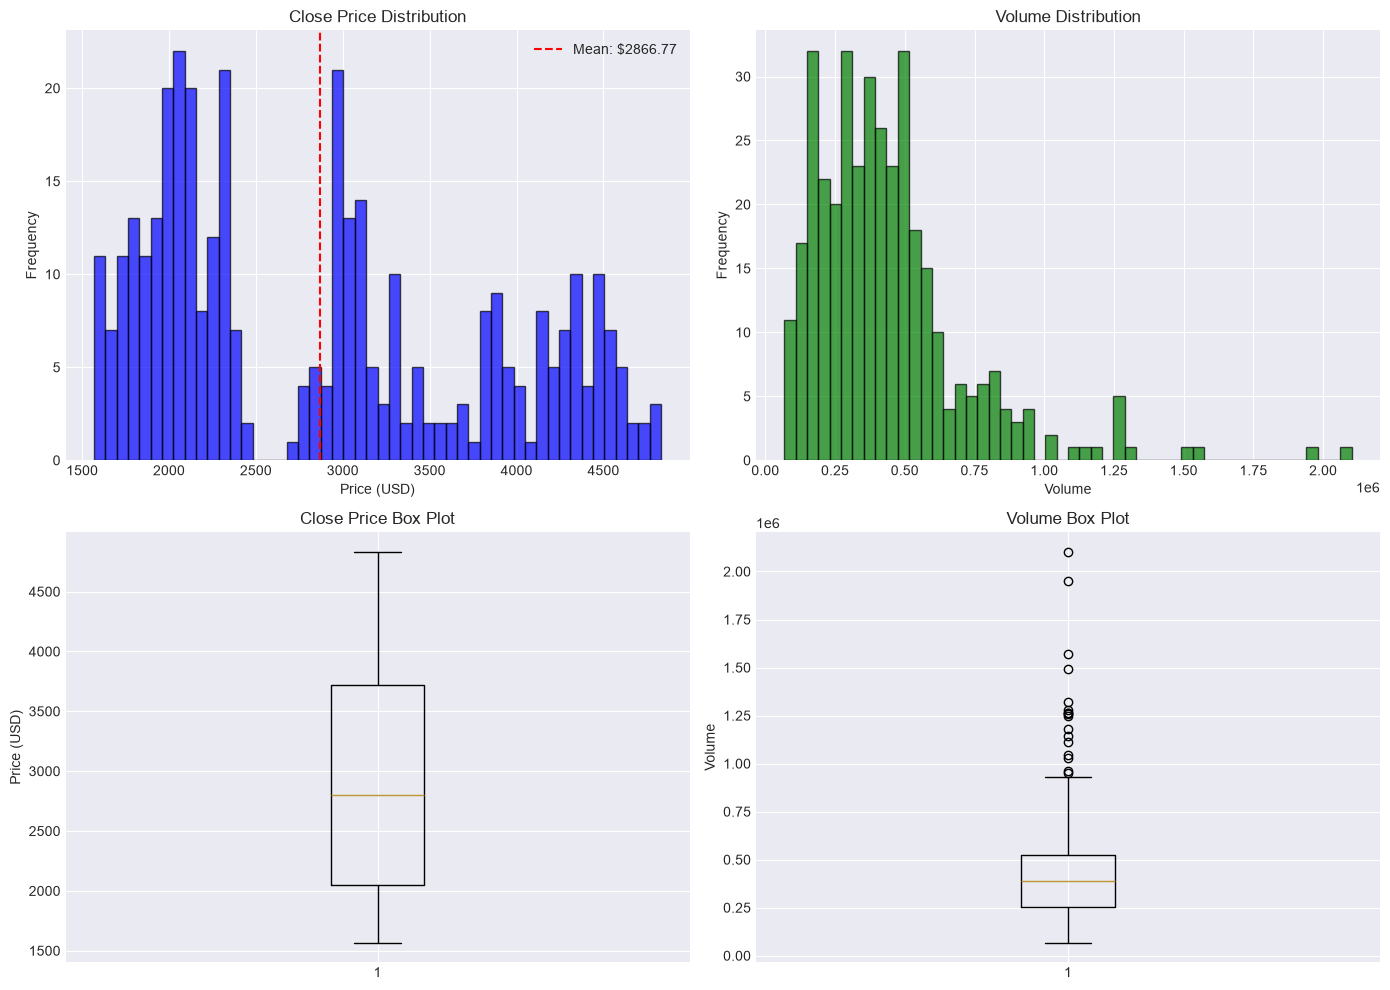

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Close price distribution
axes[0, 0].hist(df['close'], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_title('Close Price Distribution')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['close'].mean(), color='red', linestyle='--', 
                   label=f'Mean: ${df["close"].mean():.2f}')
axes[0, 0].legend()

# Volume distribution
axes[0, 1].hist(df['volume'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Volume Distribution')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].set_ylabel('Frequency')

# Box plot for price
axes[1, 0].boxplot(df['close'])
axes[1, 0].set_title('Close Price Box Plot')
axes[1, 0].set_ylabel('Price (USD)')

# Box plot for volume
axes[1, 1].boxplot(df['volume'])
axes[1, 1].set_title('Volume Box Plot')
axes[1, 1].set_ylabel('Volume')

plt.tight_layout()
plt.show()

## 7. Daily Returns Analysis

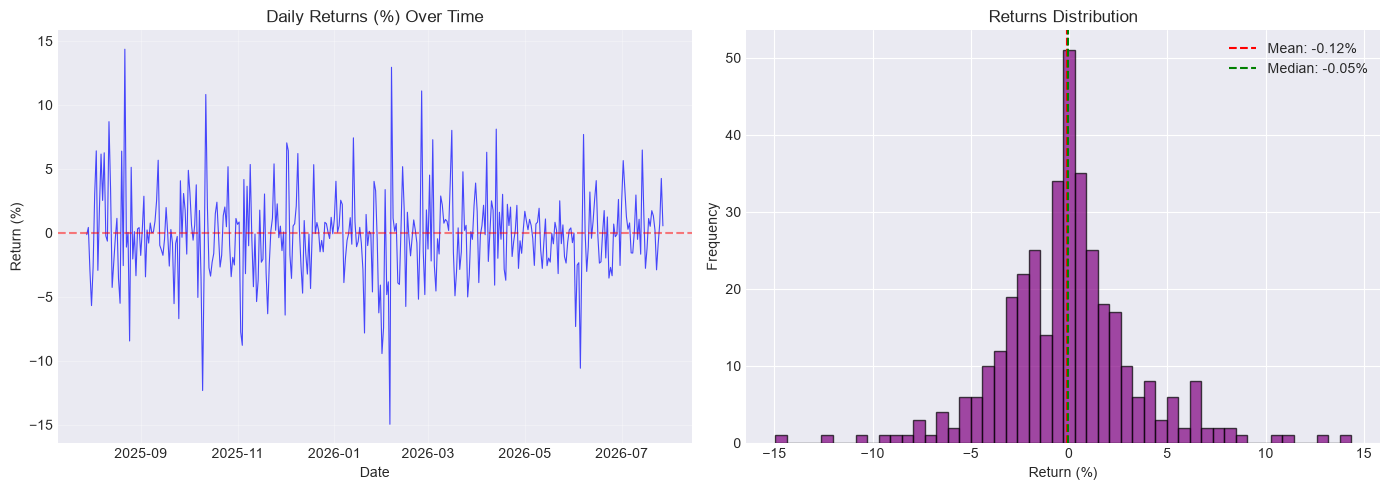

📊 Returns Statistics:
   Mean: -0.12%
   Std Dev: 3.46%
   Skewness: 0.16
   Kurtosis: 2.74


In [8]:
# Calculate returns
df['returns'] = df['close'].pct_change() * 100
df['log_returns'] = np.log(df['close'] / df['close'].shift(1)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Returns over time
axes[0].plot(df['date'], df['returns'], color='blue', alpha=0.7, linewidth=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Daily Returns (%) Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return (%)')
axes[0].grid(True, alpha=0.3)

# Returns distribution
axes[1].hist(df['returns'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(df['returns'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["returns"].mean():.2f}%')
axes[1].axvline(df['returns'].median(), color='green', linestyle='--', 
                label=f'Median: {df["returns"].median():.2f}%')
axes[1].set_title('Returns Distribution')
axes[1].set_xlabel('Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("📊 Returns Statistics:")
print(f"   Mean: {df['returns'].mean():.2f}%")
print(f"   Std Dev: {df['returns'].std():.2f}%")
print(f"   Skewness: {df['returns'].skew():.2f}")
print(f"   Kurtosis: {df['returns'].kurtosis():.2f}")